In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [5]:
orders = pd.read_csv('final_df.csv')

# Remove unnecessary columns 
orders = orders.drop(['Survey ResponseID'], axis=1)

# Remove null values
orders.isnull().sum()
orders = orders.dropna()

# Convert Order Date into datetime
orders['Order Date'] = pd.to_datetime(orders['Order Date'])

# Extract year from Order Date
orders['Year'] = orders['Order Date'].dt.year

# Sort 'Order Date' in ascending order
orders = orders.sort_values(by='Order Date', ascending=True)

# Calculate total sales in a new column
orders['Total Sales'] = orders['Purchase Price Per Unit'] * orders['Quantity']

# Group states by geographic region under a new column `Region`
def regions(state):
    if state in ['NY', 'NJ', 'PA', 'MA', 'CT', 'RI', 'NH', 'VT', 'ME', 'MD', 'DE']:
        return 'Northeast'
    elif state in ['WA', 'OR', 'CA', 'NV', 'UT', 'ID', 'MT', 'WY', 'CO', 'AK', 'HI']:
        return 'West'
    elif state in ['IL', 'OH', 'MI', 'IN', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS']:
        return 'Midwest'
    elif state in ['TX', 'OK', 'NM', 'AZ']:
        return 'Southwest'
    else:  
        return 'Southeast'
orders['Region'] = orders['Shipping Address State'].apply(regions)

# Indicate US federal holidays
holidays = pd.to_datetime(['2018-01-01', '2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', # New Year's Day
                            '2018-01-15', '2019-01-21', '2020-01-20', '2021-01-18', '2022-01-17', '2023-01-16', # Martin Luther King Jr's birthday
                            '2018-02-19', '2019-02-18', '2020-02-17', '2021-02-15', '2022-02-21', '2023-02-20', # Washington's birthday
                            '2018-05-28', '2019-05-27', '2020-05-25', '2021-05-31', '2022-05-30', '2023-05-29', # Memorial Day
                            '2018-06-19', '2019-06-19', '2020-06-19', '2021-06-19', '2022-06-19', '2023-06-19', # Juneteenth National Independence Day
                            '2018-07-04', '2019-07-04', '2020-07-04', '2021-07-04', '2022-07-04', '2023-07-04', # Independence Day
                            '2018-09-03', '2019-09-02', '2020-09-07', '2021-09-06', '2022-09-05', '2023-09-04', # Labor Day
                            '2018-10-08', '2019-10-14', '2020-10-12', '2021-10-11', '2022-10-10', '2023-10-09', # Columbus Day
                            '2018-11-11', '2019-11-11', '2020-11-11', '2021-11-11', '2022-11-11', '2023-11-11', # Veterans Day
                            '2018-11-22', '2019-11-28', '2020-11-26', '2021-11-25', '2022-11-24', '2023-11-23', # Thanksgiving Day
                            '2018-12-25', '2019-12-25', '2020-12-25', '2021-12-25', '2022-12-25', '2023-12-25' # Christmas Day
])
orders['Holiday'] = np.where(orders['Order Date'].isin(holidays), 1, 0)

# Extract Day to determine if the day is a weekend
orders['Day'] = orders['Order Date'].dt.dayofweek
orders['Weekend'] = np.where(orders['Day'].isin([5, 6]), 1, 0)

orders

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Year,Total Sales,Region,Holiday,Day,Weekend
1254138,2018-01-01,14.05,1,TN,Bodyweight Strength Training Anatomy,1450429297,Books,2018,14.05,Southeast,1,0,0
1093364,2018-01-01,10.99,1,UT,Fintie Slim Shell Case for Samsung Galaxy Tab ...,B00JGHPKWQ,Electronics,2018,10.99,West,1,0,0
1254139,2018-01-01,17.95,1,TN,BalanceFrom All Purpose 1/2-Inch Extra Thick H...,B00FO9ZRYQ,Sports and Outdoors,2018,17.95,Southeast,1,0,0
875575,2018-01-01,59.99,1,VA,Dragon Ball FighterZ Day One Edition - PlaySta...,B07214P2HQ,Video Games,2018,59.99,Southeast,1,0,0
32302,2018-01-01,7.99,1,NM,"BENTOBEN Note 4 Case, Galaxy Note 4 Case, Sams...",B06XWDMXJ5,Electronics,2018,7.99,Southwest,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
574666,2022-10-31,41.99,1,MI,HUHOT Womens Long Sleeve Square Neck Ruffle Pa...,B0B8247NB6,"Clothing, Shoes and Jewellery",2022,41.99,Midwest,0,0,0
574665,2022-10-31,48.99,1,MI,VFSHOW Womens Elegant Bell Sleeve Cocktail Par...,B085XTMBSY,"Clothing, Shoes and Jewellery",2022,48.99,Midwest,0,0,0
574664,2022-10-31,53.99,1,MI,VFSHOW Womens Elegant Bell Sleeve Cocktail Par...,B09S5WKVMT,"Clothing, Shoes and Jewellery",2022,53.99,Midwest,0,0,0
464119,2022-10-31,18.45,1,FL,VTech VG101-11 DECT 6.0 Cordless Phone for Hom...,B09NZM1LXP,Electronics,2022,18.45,Southeast,0,0,0


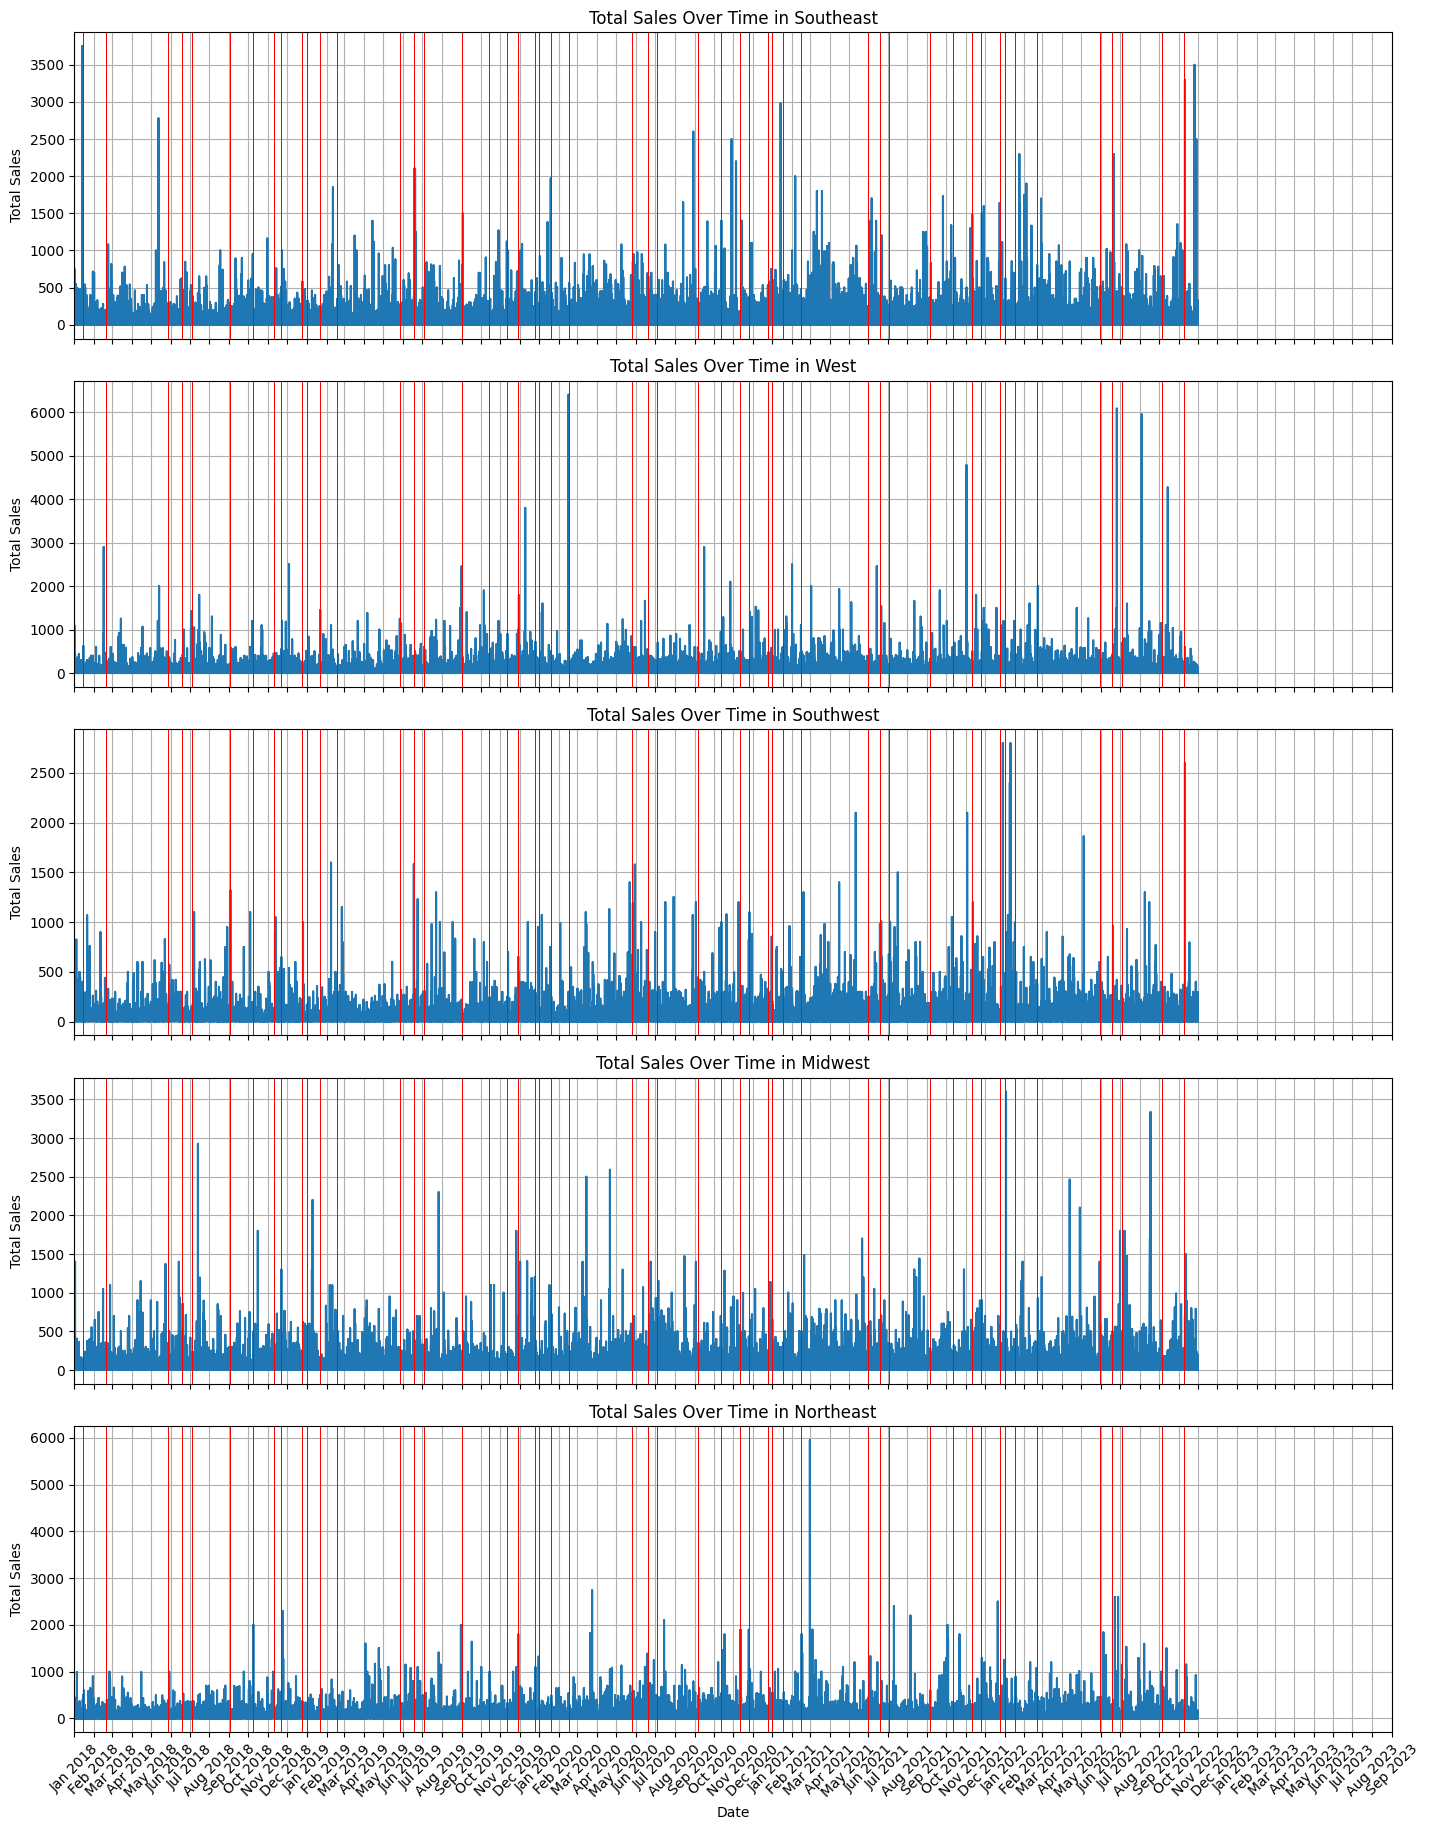

In [9]:
# Create a 5x1 grid of subplots with shared x-axis, increasing the width
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(16, 20), sharex=True)  # Increased width from 12 to 16

# Get the unique regions
regions = orders['Region'].unique()

# Plot total sales for each region in separate subplots
for i, region in enumerate(regions):
    region_sales = orders[orders['Region'] == region]
    axes[i].plot(region_sales['Order Date'], region_sales['Total Sales'])
    axes[i].set_title(f'Total Sales Over Time in {region}')
    axes[i].set_ylabel('Total Sales')
    
    # # Draw vertical lines where Total Sales >= 2000
    # high_sales_dates = region_sales[region_sales['Total Sales'] >= 2000]['Order Date']
    # for date in high_sales_dates:
    #     axes[i].axvline(x=date, color='red', linestyle='-', linewidth=0.5)  # Solid line

    # Draw vertical lines where it is a holiday
    holiday_dates = region_sales[region_sales['Holiday'] == 1]['Order Date']
    for date in holiday_dates:
        axes[i].axvline(x=date, color='red', linestyle='-', linewidth=0.5)  # Dashed line for holidays

    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid()

    # Set the x-axis limits
    axes[i].set_xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2023-09-01'))

# Set a common x-axis label
axes[-1].set_xlabel('Date')

# Formatting the x-axis to show each month
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format the ticks as "Month Year"

plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])  # Adjust layout to prevent clipping
plt.show()

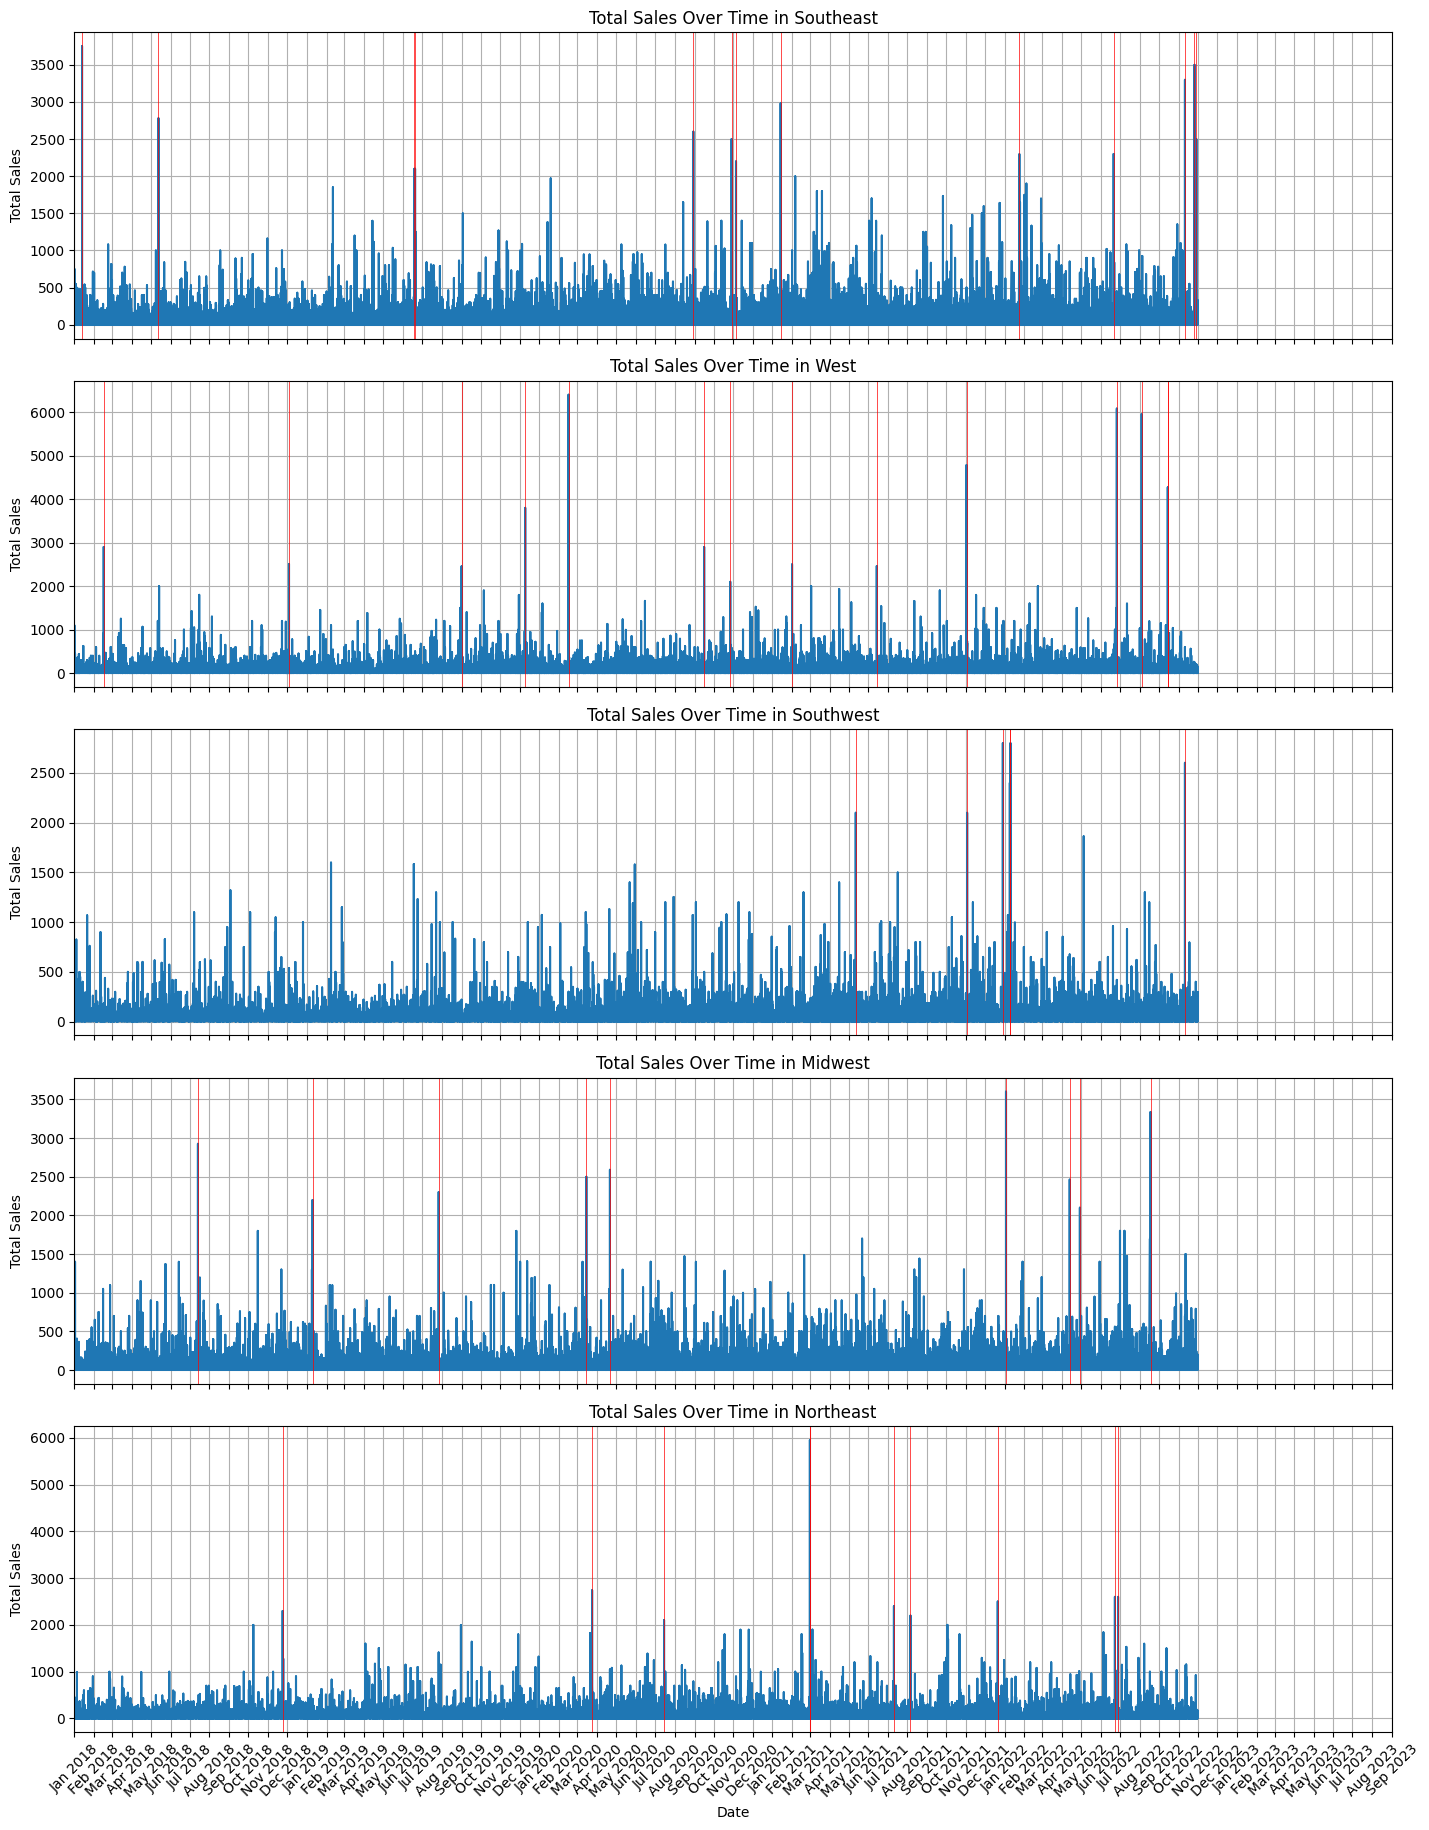

In [7]:
# Create a 5x1 grid of subplots with shared x-axis, increasing the width
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(16, 20), sharex=True)  # Increased width from 12 to 16

# Get the unique regions
regions = orders['Region'].unique()

# Plot total sales for each region in separate subplots
for i, region in enumerate(regions):
    region_sales = orders[orders['Region'] == region]
    axes[i].plot(region_sales['Order Date'], region_sales['Total Sales'])
    axes[i].set_title(f'Total Sales Over Time in {region}')
    axes[i].set_ylabel('Total Sales')
    
    # Draw vertical lines where Total Sales >= 10000
    high_sales_dates = region_sales[region_sales['Total Sales'] >= 2000]['Order Date']
    for date in high_sales_dates:
        axes[i].axvline(x=date, color='red', linestyle='-', linewidth=0.5)  # Solid line

    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid()

    # Set the x-axis limits
    axes[i].set_xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2023-09-01'))

# Set a common x-axis label
axes[-1].set_xlabel('Date')

# Formatting the x-axis to show each month
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format the ticks as "Month Year"

plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])  # Adjust layout to prevent clipping
plt.show()